In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from os.path import join as opj
from cloth_fmri.config.config import CONFIG
from cloth_fmri.utils.stats import paired_ttest, calc_p, bootstrap_ci



def plot_accuracy_bar(roi, acc, mean_acc, ci):
    ci_low, ci_high = ci

    plt.figure(figsize=(4, 6))

    # ---- bar (group mean) ----
    plt.bar(
        [0], [mean_acc],
        yerr=[[mean_acc - ci_low], [ci_high - mean_acc]],
        capsize=8,
        color="lightgray",
        edgecolor="black",
        linewidth=1.2
    )

    # ---- per-subject dots ----
    x_jitter = 0.05 * (np.random.rand(len(acc)) - 0.5)
    plt.scatter(
        x_jitter, acc,
        color="black",
        s=60,
        zorder=10,
        alpha=0.8
    )

    # Chance line
    plt.axhline(0.5, color="red", linestyle="--", linewidth=1)

    plt.title(f"ROI: {roi}", fontsize=14)
    plt.ylabel("Accuracy", fontsize=12)
    plt.xticks([])

    plt.ylim(0.3, 1.0)
    plt.tight_layout()
    plt.show()

### Plot figure 1D


 ------- ROI = tower -------
Mean accuracy = 0.543
t = 3.383, p = 0.003
Bootstrap 95% CI = [0.519, 0.567], p=0.0


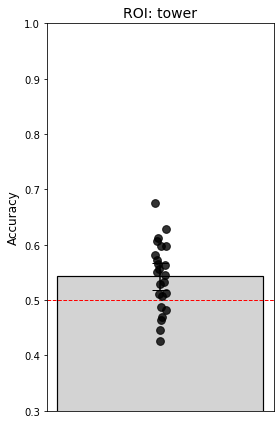


 ------- ROI = v1 -------
Mean accuracy = 0.547
t = 3.080, p = 0.005
Bootstrap 95% CI = [0.518, 0.575], p=0.0


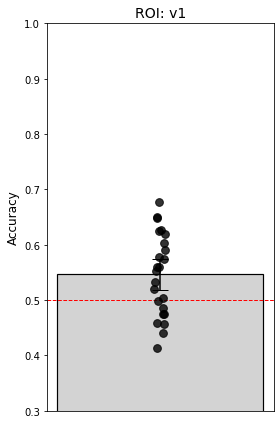


 ------- ROI = loc -------
Mean accuracy = 0.558
t = 3.973, p = 0.001
Bootstrap 95% CI = [0.529, 0.584], p=0.0


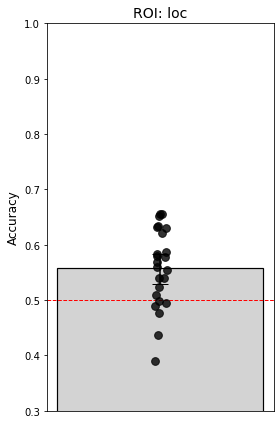

In [2]:
rois = CONFIG["rois"]
acc_all_roi = {}

for roi in rois:
    print(f'\n ------- ROI = {roi} -------')

    human_f = opj(
        CONFIG["data_root"], "derivatives", "train3scene3run", "svm_trainon-3scene3run",
        f"cloth_svm_res_scene-{roi}-0.05", "cloth_svm_avg.csv"
    )

    df = pd.read_csv(human_f)
    acc = df["avg_acc"].to_numpy()
    acc_all_roi[roi] = acc

    # Mean accuracy
    mean_acc = np.mean(acc)
    print(f"Mean accuracy = {mean_acc:.3f}")

    # T-test vs chance
    t_stat, p_val = stats.ttest_1samp(acc, popmean=0.5)
    print(f"t = {t_stat:.3f}, p = {p_val:.3f}")

    lower, upper, boots = bootstrap_ci(acc)
    ci = [lower, upper]
    print(f"Bootstrap 95% CI = [{ci[0]:.3f}, {ci[1]:.3f}], p={calc_p(boots)}")

    # Plot
    plot_accuracy_bar(roi, acc, mean_acc, ci)


In [3]:
t_stat, p_val = paired_ttest(acc_all_roi["tower"], acc_all_roi["v1"])
print(f"t-test of the two rois: t = {t_stat:.3f}, p = {p_val:.3g}")

t-test of the two rois: t = -0.181, p = 0.858
